# Day 17 — Chunking strategies

The ingest stage decides everything downstream: **if the answer's text isn't in a retrievable
chunk, no amount of good prompting or a bigger model recovers it.** We implement six chunking
strategies from scratch and measure retrieval quality for each on a fixed QA set.

## Agenda (60 min)

| # | Segment | Time |
| - | ------- | ---- |
| 0 | Why chunk at all, and what "good" means | 4 min |
| 1 | The corpus, the QA set, the metric | 8 min |
| 2 | Fixed-size, and the boundary problem | 10 min |
| 3 | Structure-aware: sentence, paragraph, recursive | 14 min |
| 4 | Semantic chunking | 10 min |
| 5 | Chunk size sweep + metadata + parent-doc retrieval | 11 min |
| 6 | Exercises + quiz | 3 min |

Kernel: **Python (ai-upskill)**.

In [1]:
import numpy as np, re
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
emb = SentenceTransformer("all-MiniLM-L6-v2")
def encode(texts): return emb.encode(texts, normalize_embeddings=True)
print("ready")

/Users/umeshkaranam/Desktop/personal/UPSKILL/AI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6640.03it/s]

ready


## 0 — Why chunk (4 min)

You can't embed a whole 30-page document as one vector — it averages every topic into mush,
and you'd stuff the entire doc into the prompt on every query. So you split it. The split
controls two things:

1. **Retrievability** — does a chunk's embedding match the queries whose answer it contains?
   (Hurt by: chunks too big → diluted; facts split across a boundary.)
2. **Answerability** — once retrieved, does the chunk contain enough to answer, with enough
   surrounding context to be unambiguous? (Hurt by: chunks too small.)

Good chunking maximises both. They pull in opposite directions on size — hence a sweet spot.

## 1 — Corpus, QA set, metric (8 min)

In [2]:
DOC = '''# Employee Handbook

## Time Off
Full-time employees accrue 1.5 vacation days per month, up to a maximum balance of 30 days.
Unused vacation above the cap is forfeited at year end. Vacation requests must be submitted at
least two weeks in advance through the HR portal, and are approved by your direct manager.
Sick leave is separate and uncapped, but absences longer than three consecutive days require
a doctor's note. Bereavement leave is five paid days for an immediate family member. Jury duty
is fully paid for up to two weeks. Parental leave is sixteen weeks at full pay for the primary
caregiver and six weeks for the secondary caregiver, and must be taken within one year of the
birth or adoption.

## Remote Work
Employees may work remotely up to three days per week with manager approval. Fully remote
arrangements require VP sign-off and are reviewed annually. The company provides a one-time
$500 home office stipend and covers internet costs up to $50 per month for approved remote
workers. Remote employees must be reachable during core hours of 10am to 3pm in their local
time zone. Coworking space memberships are reimbursed up to $200 per month in cities without
a company office.

## Expenses
Expenses under $75 do not require a receipt. Expenses of $75 or more require an itemized
receipt submitted within 14 days through the expense tool. Travel must be booked through the
corporate travel tool at least seven days before departure when possible. Meal per diem is
$60 domestic and $90 international. Alcohol is not reimbursable. Rideshare and taxi fares are
reimbursable; personal car mileage is reimbursed at the current IRS rate. Conference tickets
require manager approval before purchase.

## Equipment
New hires receive a laptop and a $200 accessories budget for a keyboard, mouse, and headset.
Laptops are replaced every three years or when they fail. Monitors are provided on request,
one per employee. Lost or stolen equipment must be reported to IT within 24 hours and may be
deducted from pay if negligence is found. Personal software licenses are not reimbursed;
request team licenses through IT.

## Security
Passwords must be at least 14 characters and are rotated every 90 days. Multi-factor
authentication is mandatory for all systems. Laptops must use full-disk encryption and lock
after five minutes of inactivity. Report suspected phishing to security@example.com. USB
storage devices are blocked by policy. Production database access requires a separate access
request approved by the data owner and is revoked automatically after 30 days.

## Performance and Pay
Performance reviews happen twice a year, in March and September. Merit raises take effect on
the first of the following month. The referral bonus is $3,000, paid after the referred hire
completes 90 days. Payday is the 15th and the last business day of each month. Expense
reimbursements are paid on the next payday after approval.
'''

QA = [
 ("how many vacation days accrue per month", "1.5 vacation days"),
 ("what is the maximum vacation balance", "maximum balance of 30 days"),
 ("how far in advance must vacation be requested", "two weeks in advance"),
 ("how much parental leave for the primary caregiver", "sixteen weeks"),
 ("how many paid days for bereavement", "five paid days"),
 ("how many days a week can I work remotely", "three days per week"),
 ("what is the home office stipend", "$500 home office stipend"),
 ("what are the remote core hours", "10am to 3pm"),
 ("how much for a coworking membership", "$200 per month"),
 ("do I need a receipt for a $50 expense", "under $75 do not require a receipt"),
 ("what is the international meal per diem", "$90 international"),
 ("what is the mileage reimbursement rate", "current IRS rate"),
 ("what accessories budget do new hires get", "$200 accessories budget"),
 ("how often are laptops replaced", "every three years"),
 ("how often are passwords rotated", "rotated every 90 days"),
 ("how long until a laptop locks when idle", "five minutes of inactivity"),
 ("when must lost equipment be reported", "within 24 hours"),
 ("is alcohol reimbursable", "Alcohol is not reimbursable"),
 ("how long until production database access is revoked", "revoked automatically after 30 days"),
 ("when are performance reviews", "March and September"),
 ("what is the referral bonus", "referral bonus is $3,000"),
]
print(f"{len(DOC)} chars, {len(QA)} questions")

2936 chars, 21 questions


In [3]:
def evaluate(chunks, k=3):
    # chunks: list of strings. Metric: does SOME retrieved chunk contain the gold fact string?
    cvec = encode(chunks)
    qvec = encode([q for q, _ in QA])
    recall, mrr = 0, 0.0
    for i, (q, gold) in enumerate(QA):
        order = np.argsort(-(cvec @ qvec[i]))
        ranks = [r for r, ci in enumerate(order) if gold.lower() in chunks[ci].lower()]
        if ranks and ranks[0] < k: recall += 1
        if ranks: mrr += 1.0 / (ranks[0] + 1)
    return dict(n_chunks=len(chunks), avg_len=int(np.mean([len(c) for c in chunks])),
                recall_at_k=recall/len(QA), mrr=mrr/len(QA))

def report(name, chunks, k=3):
    r = evaluate(chunks, k)
    print(f"{name:26s} chunks={r['n_chunks']:3d} avg_len={r['avg_len']:4d} "
          f"recall@{k}={r['recall_at_k']:.2f} mrr={r['mrr']:.2f}")
    return r

## 2 — Fixed-size chunking (10 min)

The simplest: every `N` characters (or tokens). Fast, predictable, and it **splits facts
mid-sentence**. Overlap is the usual patch.

In [4]:
def fixed(text, size, overlap=0):
    text = re.sub(r"\s+", " ", text).strip()
    step = max(1, size - overlap)
    return [text[i:i+size] for i in range(0, len(text), step)]

print("no overlap:")
for size in [120, 250, 500, 900]:
    report(f"fixed size={size}", fixed(DOC, size))
print("\nwith 20% overlap:")
for size in [120, 250, 500, 900]:
    report(f"fixed size={size} ov=20%", fixed(DOC, size, overlap=size//5))

no overlap:


fixed size=120             chunks= 25 avg_len= 117 recall@3=0.90 mrr=0.87
fixed size=250             chunks= 12 avg_len= 244 recall@3=0.86 mrr=0.81
fixed size=500             chunks=  6 avg_len= 488 recall@3=0.95 mrr=0.87
fixed size=900             chunks=  4 avg_len= 732 recall@3=1.00 mrr=0.95

with 20% overlap:


fixed size=120 ov=20%      chunks= 31 avg_len= 117 recall@3=0.95 mrr=0.91
fixed size=250 ov=20%      chunks= 15 avg_len= 241 recall@3=0.95 mrr=0.96
fixed size=500 ov=20%      chunks=  8 avg_len= 453 recall@3=1.00 mrr=0.98
fixed size=900 ov=20%      chunks=  5 avg_len= 703 recall@3=1.00 mrr=0.90


Watch the pattern: tiny chunks retrieve precisely but often lack the gold string entirely
(it's split); huge chunks contain everything but embed as a blur so `recall@3` and especially
`mrr` sag. Overlap reliably lifts recall a few points by keeping boundary-straddling facts
whole in at least one chunk — at the cost of more chunks to store and redundant text in the
prompt.

## 3 — Structure-aware chunking (14 min)

Text has structure — sentences, paragraphs, headings. Splitting on those keeps facts intact.

In [5]:
def by_sentence(text, max_chars=400):
    sents = re.split(r"(?<=[.!?])\s+", re.sub(r"\s+", " ", text).strip())
    out, cur = [], ""
    for s in sents:
        if len(cur) + len(s) <= max_chars: cur = (cur + " " + s).strip()
        else: out.append(cur); cur = s
    if cur: out.append(cur)
    return out

def by_paragraph(text):
    # split on blank lines / markdown headers, keep the header with its section
    blocks = re.split(r"\n\s*\n", text.strip())
    return [re.sub(r"\s+", " ", b).strip() for b in blocks if b.strip()]

def recursive(text, max_chars=400, seps=("\n## ", "\n\n", ". ", " ")):
    text = text.strip()
    if len(text) <= max_chars: return [text]
    sep = next((s for s in seps if s in text), None)
    if sep is None: return [text[i:i+max_chars] for i in range(0, len(text), max_chars)]
    parts, out, cur = text.split(sep), [], ""
    for p in parts:
        p = (sep + p) if cur or out else p
        if len(cur) + len(p) <= max_chars:
            cur += p
        else:
            if cur: out.append(cur.strip())
            cur = p if len(p) <= max_chars else ""
            if len(p) > max_chars: out += recursive(p, max_chars, seps)
    if cur.strip(): out.append(cur.strip())
    return [c for c in out if c]

report("sentence (max 400)", by_sentence(DOC, 400))
report("paragraph / section", by_paragraph(DOC))
report("recursive (max 400)", recursive(DOC, 400))

sentence (max 400)         chunks=  8 avg_len= 365 recall@3=1.00 mrr=0.94
paragraph / section        chunks=  7 avg_len= 417 recall@3=1.00 mrr=1.00
recursive (max 400)        chunks= 12 avg_len= 243 recall@3=1.00 mrr=1.00


{'n_chunks': 12, 'avg_len': 243, 'recall_at_k': 1.0, 'mrr': 1.0}

- **Sentence packing** keeps each fact whole and packs sentences up to a budget — a solid
  default.
- **Paragraph / section** aligns chunks with the document's own topic boundaries; here each
  `## Section` becomes one chunk, so a query about vacation retrieves the entire Time Off
  section. Great when sections are short; bad when one section is 5 pages.
- **Recursive** (the LangChain `RecursiveCharacterTextSplitter` idea): try to split on the
  biggest separator that fits (headings → blank lines → sentences → spaces), recursing when a
  piece is still too big. It's the pragmatic default: structure-aware but size-bounded.

## 4 — Semantic chunking (10 min)

Split where the *topic* changes: embed each sentence, and start a new chunk wherever adjacent
sentences are dissimilar enough. No fixed size — chunks are as long as the topic runs.

In [6]:
def semantic(text, pct=25):
    sents = re.split(r"(?<=[.!?])\s+", re.sub(r"\s+", " ", text).strip())
    sents = [s for s in sents if s]
    if len(sents) < 3: return sents
    v = encode(sents)
    gaps = 1 - np.sum(v[:-1] * v[1:], axis=1)          # cosine distance between neighbours
    threshold = np.percentile(gaps, 100 - pct)          # split at the biggest `pct`% of gaps
    out, cur = [], [sents[0]]
    for i, g in enumerate(gaps):
        if g >= threshold:
            out.append(" ".join(cur)); cur = [sents[i+1]]
        else:
            cur.append(sents[i+1])
    out.append(" ".join(cur))
    return out

for pct in [15, 25, 40]:
    report(f"semantic (split top {pct}%)", semantic(DOC, pct))

sc = semantic(DOC, 25)
print("\nsemantic chunk boundaries:")
for c in sc: print(f"  [{len(c):3d}] {c[:75]}...")

semantic (split top 15%)   chunks=  6 avg_len= 487 recall@3=1.00 mrr=0.98
semantic (split top 25%)   chunks= 10 avg_len= 292 recall@3=1.00 mrr=1.00


semantic (split top 40%)   chunks= 15 avg_len= 194 recall@3=1.00 mrr=1.00

semantic chunk boundaries:
  [1096] # Employee Handbook ## Time Off Full-time employees accrue 1.5 vacation day...
  [367] Coworking space memberships are reimbursed up to $200 per month in cities w...
  [ 52] Meal per diem is $60 domestic and $90 international....
  [131] Alcohol is not reimbursable. Rideshare and taxi fares are reimbursable; per...
  [ 60] Conference tickets require manager approval before purchase....
  [215] ## Equipment New hires receive a laptop and a $200 accessories budget for a...
  [420] Lost or stolen equipment must be reported to IT within 24 hours and may be ...
  [ 50] Report suspected phishing to security@example.com....
  [175] USB storage devices are blocked by policy. Production database access requi...
  [354] ## Performance and Pay Performance reviews happen twice a year, in March an...


Semantic chunking shines on messy documents where structure markers are unreliable
(transcripts, scraped HTML, OCR). Costs: an embedding pass over every sentence at ingest, a
threshold to tune, and chunks of unpredictable size (can blow your prompt budget). On a
well-structured doc like this handbook, recursive/section chunking usually matches it for less
cost.

## 5 — Size sweep, metadata, parent-doc retrieval (11 min)

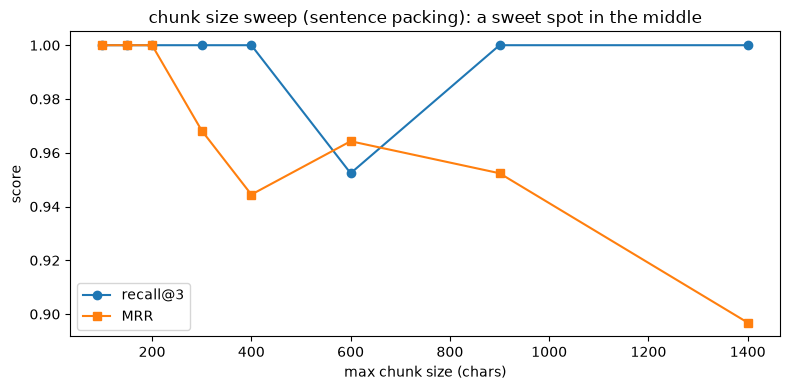

too small: fact fragmented / no context to embed. too big: topic blur, imprecise match.


In [7]:
sizes = [100, 150, 200, 300, 400, 600, 900, 1400]
rec = [evaluate(by_sentence(DOC, s))["recall_at_k"] for s in sizes]
mrr = [evaluate(by_sentence(DOC, s))["mrr"] for s in sizes]
plt.figure(figsize=(8,4))
plt.plot(sizes, rec, "o-", label="recall@3")
plt.plot(sizes, mrr, "s-", label="MRR")
plt.xlabel("max chunk size (chars)"); plt.ylabel("score"); plt.legend()
plt.title("chunk size sweep (sentence packing): a sweet spot in the middle")
plt.tight_layout(); plt.show()
print("too small: fact fragmented / no context to embed. too big: topic blur, imprecise match.")

In [8]:
# Metadata: prepend the section heading to each chunk. Helps the embedding AND the LLM.
def sections(text, max_chars=300):
    out = []
    for block in re.split(r"\n(?=## )", text.strip()):
        block = block.strip()
        m = re.match(r"#+\s*(.+)", block)
        head = m.group(1).strip() if m else "Overview"
        body = re.sub(r"^#+.*(?:\n|$)", "", block).strip()      # drop the heading line only
        for s in by_sentence(body, max_chars):
            if s.strip():
                out.append(f"[{head}] {s.strip()}")
    return out

plain = by_sentence(DOC, 300)
tagged = sections(DOC)
report("sentence 300 (plain)", plain)
report("sentence 300 + heading", tagged)
print("\n-> the heading tag adds topical signal that a short chunk otherwise lacks, and gives")
print("   the LLM the section name for free.")

sentence 300 (plain)       chunks= 12 avg_len= 243 recall@3=1.00 mrr=0.97
sentence 300 + heading     chunks= 13 avg_len= 229 recall@3=1.00 mrr=1.00

-> the heading tag adds topical signal that a short chunk otherwise lacks, and gives
   the LLM the section name for free.


In [9]:
# Parent-document (small-to-big) retrieval: retrieve on SMALL chunks for precision, then
# return the surrounding PARENT section to the LLM for context.
small = []
parent_of = []
for si, block in enumerate(re.split(r"\n(?=## )", DOC)):
    parent_text = re.sub(r"\s+", " ", block).strip()
    for s in by_sentence(block, 160):
        small.append(s); parent_of.append(parent_text)

svec = encode(small)
def small_to_big(query, k=2):
    order = np.argsort(-(svec @ encode([query])[0]))[:k]
    seen, parents = set(), []
    for i in order:
        if parent_of[i] not in seen:
            seen.add(parent_of[i]); parents.append(parent_of[i])
    return parents

q = "do I need a receipt for a $50 expense"
print("small chunk hit -> returns parent section:")
print(" ", small_to_big(q)[0][:200], "...")
# metric: does the returned parent contain the gold fact?
hit = np.mean([any(gold.lower() in p.lower() for p in small_to_big(q)) for q, gold in QA])
print(f"\nsmall-to-big: gold fact in returned parent = {hit:.2f}  (precision of small + context of big)")

small chunk hit -> returns parent section:
  ## Expenses Expenses under $75 do not require a receipt. Expenses of $75 or more require an itemized receipt submitted within 14 days through the expense tool. Travel must be booked through the corpor ...



small-to-big: gold fact in returned parent = 1.00  (precision of small + context of big)


### Strategy picker

| Document type | Start with |
| ------------- | ---------- |
| Clean markdown / structured docs | recursive, or section-based if sections are short |
| Prose (articles, books) | sentence packing, ~300–500 chars, 15% overlap |
| Transcripts / scraped / OCR | semantic chunking |
| Q&A pairs, code, tables | keep each unit whole (don't split a function / a row) |
| Anything where precision matters | small-to-big (retrieve small, return parent) |

Always: attach metadata (title, section, source, date) to every chunk. Always measure
recall@k on a real QA set before and after a chunking change — it's cheap and it's the only
thing that tells you if you helped.

## 6 — Exercises

1. **Overlap sweep.** For `fixed(DOC, 250, overlap=o)` with `o` in `[0, 25, 50, 100, 150]`,
   plot recall@3 and the number of chunks. What's the marginal recall per extra chunk?
2. **k sensitivity by strategy.** For each strategy, compute recall@1, @3, @5. Which strategy
   needs the fewest chunks in context to hit recall ≥ 0.9?
3. **Break a fact.** Find a chunk size where "MFA is mandatory" and its qualifier land in
   different fixed chunks so the query "is 2FA required" misses. Fix with overlap or sentence
   splitting.
4. **Semantic threshold.** Sweep `pct` in `semantic()` from 5 to 60. Plot recall@3 and mean
   chunk length. Where does it over-split (chunks too tiny) vs under-split (one giant chunk)?
5. **Metadata value.** Compare `report()` for plain vs heading-tagged chunks at sizes 150,
   300, 600. At which size does the heading help most, and why?
6. **Small-to-big cost.** Measure the mean token count fed to the LLM for (a) top-3 sentence
   chunks vs (b) small-to-big top-2 parents. What are you trading?

In [10]:
# ---- Solution 1 ----
os_ = [0, 25, 50, 100, 150]
recs = [evaluate(fixed(DOC, 250, o))["recall_at_k"] for o in os_]
ns   = [len(fixed(DOC, 250, o)) for o in os_]
for o, r, n in zip(os_, recs, ns):
    print(f"overlap={o:3d}  recall@3={r:.2f}  chunks={n}")
print("marginal recall per extra chunk from 0->150 overlap:",
      round((recs[-1]-recs[0]) / max(1, ns[-1]-ns[0]), 3))

overlap=  0  recall@3=0.86  chunks=12
overlap= 25  recall@3=0.95  chunks=14
overlap= 50  recall@3=0.95  chunks=15
overlap=100  recall@3=1.00  chunks=20
overlap=150  recall@3=1.00  chunks=30
marginal recall per extra chunk from 0->150 overlap: 0.008


In [11]:
# ---- Solution 2 ----
strategies = {
 "fixed 250 ov20": fixed(DOC, 250, 50),
 "sentence 400": by_sentence(DOC, 400),
 "paragraph": by_paragraph(DOC),
 "recursive 400": recursive(DOC, 400),
 "semantic 25%": semantic(DOC, 25),
}
print(f"{'strategy':18s} {'r@1':>5} {'r@3':>5} {'r@5':>5} {'#chunks':>8}")
for name, ch in strategies.items():
    r1, r3, r5 = (evaluate(ch, k)["recall_at_k"] for k in (1, 3, 5))
    print(f"{name:18s} {r1:>5.2f} {r3:>5.2f} {r5:>5.2f} {len(ch):>8}")

strategy             r@1   r@3   r@5  #chunks


fixed 250 ov20      0.95  0.95  1.00       15


sentence 400        0.90  1.00  1.00        8


paragraph           1.00  1.00  1.00        7


recursive 400       1.00  1.00  1.00       12


semantic 25%        1.00  1.00  1.00       10


In [12]:
# ---- Solution 6 ----
import tiktoken
tk = tiktoken.get_encoding("cl100k_base")
qv = encode([q for q, _ in QA])
sent_chunks = by_sentence(DOC, 300); cv = encode(sent_chunks)
a_tokens = np.mean([sum(len(tk.encode(sent_chunks[i]))
                        for i in np.argsort(-(cv @ qv[j]))[:3]) for j in range(len(QA))])
b_tokens = np.mean([sum(len(tk.encode(p)) for p in small_to_big(q, k=2)) for q, _ in QA])
print(f"S6: top-3 sentence chunks  ~{a_tokens:.0f} tokens/query")
print(f"    small-to-big top-2 parents ~{b_tokens:.0f} tokens/query")
print("    trade: small-to-big spends more prompt tokens to guarantee the retrieved fact has")
print("    its full surrounding context (fewer 'retrieved but unanswerable' cases).")

S6: top-3 sentence chunks  ~150 tokens/query
    small-to-big top-2 parents ~141 tokens/query
    trade: small-to-big spends more prompt tokens to guarantee the retrieved fact has
    its full surrounding context (fewer 'retrieved but unanswerable' cases).


### Solutions 3, 4, 5 (sketch)

**S3:** at `fixed(DOC, ~130)` the Security section's "Multi-factor authentication is mandatory
for all systems." can land such that "mandatory for all systems" starts a new chunk. The query
*"is 2FA required"* then matches neither half well. `by_sentence` keeps the sentence whole;
overlap ≥ 20% also covers it.

**S4:** low `pct` (5–10) → almost no splits → one huge chunk, recall collapses on specific
questions (blur). High `pct` (50–60) → splits at every mild topic wobble → sentence-sized
chunks, recall drops because facts lose context and embed noisily. Best around 20–30% on this
doc; mean chunk length ~150–350 chars there.

**S5:** the heading helps **most at small sizes** (150): a 150-char chunk from the Expenses
section might be just "Meal per diem is $60 domestic and $90 international." — prepending
`[Expenses]` adds the topical anchor the short text lacks. At 600 chars the chunk already
contains enough context that the heading adds little.

## Self-check quiz

1. What two competing properties does chunk size trade off?
2. Why does a very large chunk hurt retrieval precision even though it "contains the answer"?
3. What does overlap fix, and what does it cost?
4. When is semantic chunking worth its extra cost over recursive chunking?
5. Explain small-to-big (parent-document) retrieval and what it optimises.
6. You changed your chunker and answer quality dropped. What's the first thing to measure?
7. Why prepend the section heading to each chunk?

### Answer key

1. Retrievability (chunk embedding matches the right queries — hurt by chunks too big or facts
   split) vs answerability (chunk has enough context to actually answer — hurt by chunks too
   small).
2. Its embedding is the average of several topics, so it matches many queries weakly and few
   queries strongly — it gets retrieved for the wrong questions and ranked low for the right
   one (MRR drops).
3. It keeps a fact that straddles a chunk boundary intact in at least one chunk. Cost: more
   chunks to store/index and redundant text repeated across chunks (and in the prompt).
4. When the document lacks reliable structure markers — transcripts, scraped HTML, OCR — so
   heading/paragraph splitting produces bad boundaries. On clean structured docs, recursive
   usually matches it for far less compute.
5. Retrieve against small, precise chunks (good match quality), but pass the larger parent
   section to the LLM. Optimises retrieval precision and answer context simultaneously, at the
   cost of more prompt tokens.
6. recall@k on a QA set: did some retrieved chunk actually contain the gold fact? Almost every
   "RAG got worse" is a retrieval-recall regression, and chunking is the usual cause.
7. A short chunk often lacks topical signal; the heading adds it (improving the embedding
   match) and hands the LLM the section name for free (better, more citable answers).

## Where this goes next

- **Day 18 — Build a RAG pipeline:** assemble Days 13–17 into a working pipeline over a real
  document set, with the Anthropic API doing generation and a small eval harness scoring it.